In [1]:
import sys
sys.path.append('../src/training-on-CM2.6')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap
import cmocean

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.plot_helpers import *

%load_ext autoreload
%autoreload 3

In [10]:
from helpers.ann_tools import ANN_equivariant, ANN
print(ANN_equivariant(24).count_parameters())
print(ANN(layer_sizes=[27,20,3]).count_parameters())

67
623


In [2]:
ds = read_datasets(['test'], [4,9,12,15], subfilter='subfilter', FGR=3)
ds2d = ds['test-4'].select2d()

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-15


In [50]:
import itertools
rots  = [90, 0]
refxs = [True, False]
refys = [True, False]
augment = itertools.product(rots, refxs, refys)

ann_equivariant = ANN_equivariant()

dds = ds['test-4'].select2d(zl=0,time=0)
kw = dict(ann_Tall = ann_equivariant, stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
for rotation, reflect_x, reflect_y in augment:
    inv_kw = dict(rotation=rotation, reflect_y=reflect_x, reflect_x=reflect_y)

    control = dds.state.ANN(**kw)
    transformed = dds.state.ANN(**kw, **inv_kw)
    print(inv_kw)
    for key in ['Txx', 'Txy', 'Tyy']:
        print(key, np.linalg.norm(control[key]-transformed[key]) / np.linalg.norm(control[key]))
    

{'rotation': 90, 'reflect_y': True, 'reflect_x': True}
Txx 3.1579880568420237e-07
Txy 4.5964929435636486e-07
Tyy 3.287710834112733e-07
{'rotation': 90, 'reflect_y': True, 'reflect_x': False}
Txx 1.357760430440662e-07
Txy 2.3252937105454564e-07
Tyy 1.313798294411203e-07
{'rotation': 90, 'reflect_y': False, 'reflect_x': True}
Txx 2.3805938207245182e-07
Txy 3.343301886660648e-07
Tyy 2.3184929810455806e-07
{'rotation': 90, 'reflect_y': False, 'reflect_x': False}
Txx 3.359980974096065e-07
Txy 4.1354890500639784e-07
Tyy 3.096416090178528e-07
{'rotation': 0, 'reflect_y': True, 'reflect_x': True}
Txx 2.2274899435096438e-07
Txy 3.2956997479962887e-07
Tyy 2.3266721748015883e-07
{'rotation': 0, 'reflect_y': True, 'reflect_x': False}
Txx 3.3433855557738113e-07
Txy 4.6198407291033745e-07
Tyy 3.218262474696798e-07
{'rotation': 0, 'reflect_y': False, 'reflect_x': True}
Txx 3.470470223724771e-07
Txy 4.0754005498872424e-07
Tyy 3.0112020901455865e-07
{'rotation': 0, 'reflect_y': False, 'reflect_x': Fals

# Convert equivariant ANN to regular and back

In [3]:
from helpers.ann_tools import import_ANN, ANN_equivariant, equivariant_to_regular_ANN, regular_to_equivariant_ANN
ann_equivariant = ANN_equivariant()
print(ann_equivariant.count_parameters())
ann_transformed = equivariant_to_regular_ANN(ann_equivariant)
print(ann_transformed.count_parameters())
ann_equivariant_back = regular_to_equivariant_ANN(ann_transformed, stencil_size=3)

45
499
Training starts on device cpu, number of samples 800000
[1/10] [3.99/35.88] Loss: [0.014665, 0.000950]
[2/10] [3.92/31.63] Loss: [0.000382, 0.000083]
[3/10] [3.95/27.66] Loss: [0.000015, 0.000002]
[4/10] [3.90/23.63] Loss: [0.000001, 0.000000]
[5/10] [3.89/19.64] Loss: [0.000000, 0.000000]
[6/10] [3.90/15.69] Loss: [0.000000, 0.000000]
[7/10] [3.90/11.76] Loss: [0.000000, 0.000000]
[8/10] [3.90/7.84] Loss: [0.000000, 0.000000]
[9/10] [3.89/3.91] Loss: [0.000000, 0.000000]
[10/10] [3.92/0.00] Loss: [0.000000, 0.000000]


In [4]:
dds = ds['test-4'].select2d(zl=0,time=0)
kw = dict(stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
control = dds.state.ANN(ann_Tall = ann_equivariant, **kw)
transformed = dds.state.ANN(ann_Tall = ann_transformed, **kw)
control_back = dds.state.ANN(ann_Tall = ann_equivariant_back, **kw)
for key in ['Txx', 'Txy', 'Tyy']:
    print(key, np.linalg.norm(control[key]-transformed[key]) / np.linalg.norm(control[key]))
    print(key, 'back', np.linalg.norm(control[key]-control_back[key]) / np.linalg.norm(control[key]))

Txx 1.0812249936427862e-07
Txx back 0.0001243705186622809
Txy 2.599915715620139e-07
Txy back 0.0003410342182747226
Tyy 1.1378914007237779e-07
Tyy back 0.00012037057494155217


Correlation: 0.9999999999999375
Relative Error: 3.3584998160399264e-07
R2 =  0.9999999999998722
R2 max =  0.999999999999873
Optinal scaling: 0.9999999726707085
Nans [test/control]: [15337, 15337]


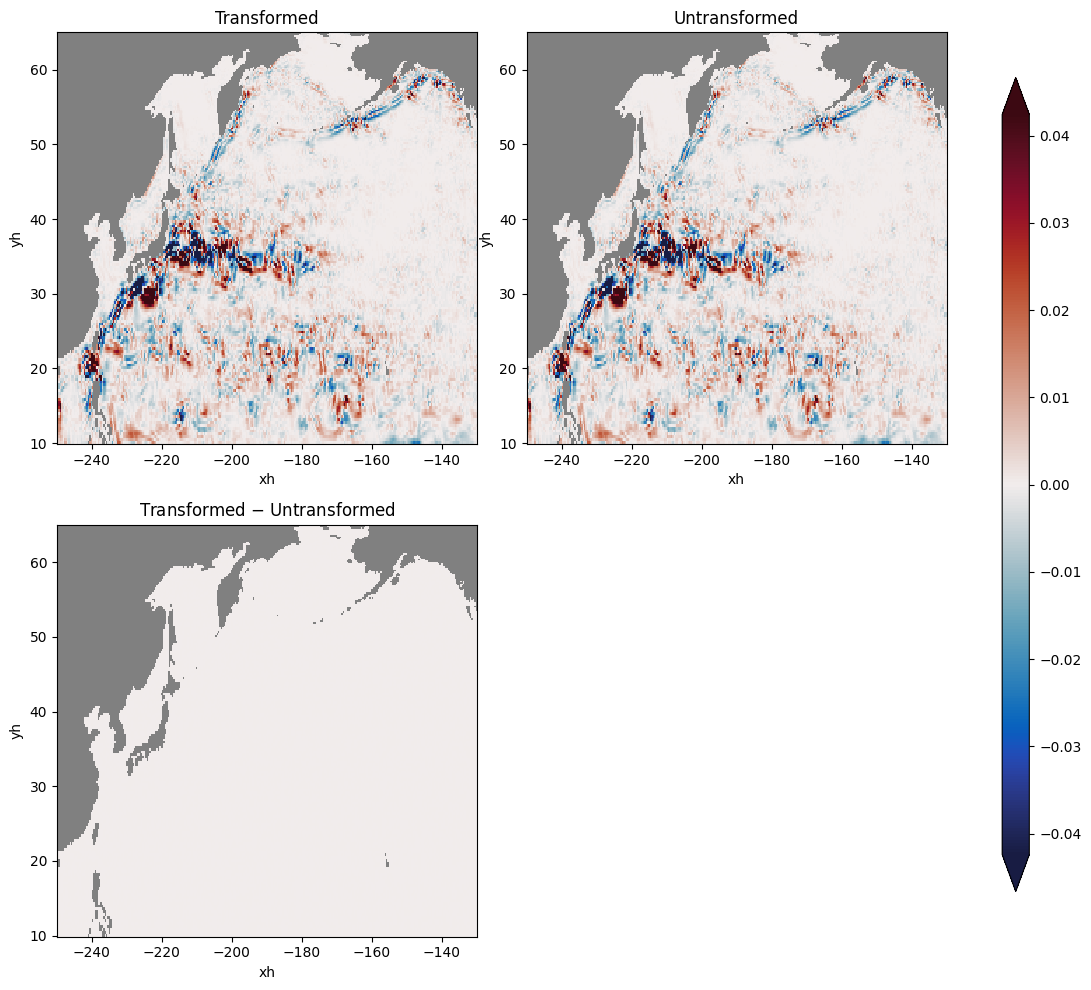

In [5]:
dds = ds['test-4'].select2d(zl=0,time=0)
kw = dict(ann_Tall = ann_equivariant_back, stencil_size=3, dimensional_scaling=True, gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
key = 'Txy'
inv_kw = dict(rotation=90, reflect_y=True, reflect_x=True)

Txy = dds.state.ANN(**kw)[key]
Txy_rotated = dds.state.ANN(**kw, **inv_kw)[key]
compare(dds.nanvar(Txy_rotated), dds.nanvar(Txy), selector=select_Pacific, label_control='Untransformed', label_test='Transformed');

# Train equivariant ANN

In [33]:
from helpers.train_ann import train_ANN

In [35]:
# test training of regular ANN
train_ANN()

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-9
Factor: 9, depth: 0, MSE train/validate: [1.981614, 2.141115]
Iter/num_iters [1/50]. Iter time/Remaining time in seconds: [1.99/97.4]
Factor: 9, depth: 0, MSE train/validate: [1.714363, 1.595523]
Iter/num_iters [2/50]. Iter time/Remaining time in seconds: [1.92/93.8]
Factor: 9, depth: 0, MSE train/validate: [1.390622, 1.246336]
Iter/num_iters [3/50]. Iter time/Remaining time in seconds: [1.77/88.9]
Factor: 9, depth: 0, MSE train/validate: [1.195736, 1.161262]
Iter/num_iters [4/50]. Iter time/Remaining time in seconds: [1.83/86.3]
Factor: 9, depth: 0, MSE train/validate: [1.090477, 1.013372]
Iter/num_iters [5/50]. Iter time/Remaining time in seconds: [1.75/83.3]
Factor: 9, depth: 0, MSE train/validate: [0.969380, 0.956068]
Iter/num_iters [6/50]. Iter time/Remaining time in seconds: [1.76/80.8]
Factor: 9, depth: 0, MSE train/validat

(ANN(
   (layers): Sequential(
     (0): Linear(in_features=27, out_features=32, bias=True)
     (1): Linear(in_features=32, out_features=3, bias=True)
   )
 ),
 <xarray.Dataset> Size: 816B
 Dimensions:       (factor: 1, depth: 1, iter: 50)
 Coordinates:
   * factor        (factor) int64 8B 9
   * depth         (depth) int64 8B 0
 Dimensions without coordinates: iter
 Data variables:
     MSE_train     (iter, factor, depth) float64 400B 1.982 1.714 ... 0.7603
     MSE_validate  (iter, factor, depth) float64 400B 2.141 1.596 ... 0.6374)

In [57]:
train_ANN(equivariant=True, symmetries='All', loss_function='fluxes', factors=[4])

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-4
Factor: 4, depth: 0, MSE train/validate: [134.626266, 136.828522]
Iter/num_iters [1/50]. Iter time/Remaining time in seconds: [13.49/661.1]
Factor: 4, depth: 0, MSE train/validate: [119.072937, 110.574646]
Iter/num_iters [2/50]. Iter time/Remaining time in seconds: [13.84/656.1]
Factor: 4, depth: 0, MSE train/validate: [110.205696, 98.308586]
Iter/num_iters [3/50]. Iter time/Remaining time in seconds: [13.94/646.7]
Factor: 4, depth: 0, MSE train/validate: [86.971741, 97.415154]
Iter/num_iters [4/50]. Iter time/Remaining time in seconds: [13.76/632.9]
Factor: 4, depth: 0, MSE train/validate: [86.219803, 84.847610]
Iter/num_iters [5/50]. Iter time/Remaining time in seconds: [14.32/624.2]
Factor: 4, depth: 0, MSE train/validate: [76.161163, 75.856117]
Iter/num_iters [6/50]. Iter time/Remaining time in seconds: [14.61/615.8]
Factor: 4

KeyboardInterrupt: 

# Test saving to file

In [3]:
import sys
import torch
sys.path.append('../src/training-on-CM2.6')
from helpers.ann_tools import ANN_equivariant, export_ANN, import_ANN
ann_control = ANN_equivariant()
export_ANN(ann_control, input_norms=torch.ones(27), output_norms=torch.ones(3))

Saving additionally weights of equivariant part of ANN


In [4]:
ann_test = import_ANN()
for p in ann_test.parameters():
    print(p)

for p in ann_control.parameters():
    print(p)

Returning equivariant ANN instead
{'hidden_layer_size': 16, 'stencil_size': 3}
Parameter containing:
tensor([0., 0.], requires_grad=True)
Parameter containing:
tensor([-0.0305,  0.7726,  0.7892, -0.1311,  0.4182, -0.0730,  0.0456,  0.6465,
        -1.3148,  0.2493, -0.8542, -0.2568,  0.2304, -0.0591,  0.8964, -0.5648,
        -0.5562, -0.2886, -0.6422,  0.0485,  0.2832,  0.0018, -1.1543, -0.5083,
        -0.2745, -0.2643, -0.0151,  0.9215, -0.6431,  0.6715, -0.2940,  0.5309,
         0.5700,  0.6243, -1.3280, -0.3922], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)
Parameter containing:
tensor([-0.2855, -0.6874, -0.9245, -0.4048,  0.2464, -0.4745],
       requires_grad=True)
Parameter containing:
tensor([0., 0.], requires_grad=True)
Parameter containing:
tensor([-0.0305,  0.7726,  0.7892, -0.1311,  0.4182, -0.0730,  0.0456,  0.6465,
        -1.3148,  0.2493, -0.8542, -0.2568,  0.2304, -0.0591,  0.8964, -0.5648,
        -0.5562, -0.2886, -0.6422,  0.0485,  0.

In [5]:
x = torch.randn(10,27)
ann_test(x) - ann_control(x)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<SubBackward0>)

# Compare offline skill of equivariant vs regular ANNs

In [111]:
def read_skill(exp='subfilter/FGR3/EXP1', factors=[4,9,12,15], base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):
    ds = {}
    for factor in factors:
        data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-{factor}.nc', chunks={'zl':1})
        data['zl'] = -data['zl']
        try:
            data['Tdd_pred'] = (data['Txx_pred'] - data['Tyy_pred']) * 0.5
            data['Ttr_pred'] = (data['Txx_pred'] + data['Tyy_pred']) * 0.5
            data['Tdd'] = (data['Txx'] - data['Tyy']) * 0.5
            data['Ttr'] = (data['Txx'] + data['Tyy']) * 0.5
        except:
            pass
        ds[factor] = data
        ds['stats'] = xr.open_dataset(f'{base_path}/{exp}/model/logger.nc')
        
    return ds

In [122]:
dd ={}
for key in ['128',  '128-v1',  '16',  '16-v1',  '24',  '24-v1',  '32',  '32-v1',  '64',  '64-v1']:
    try:
        dd[key] = read_skill(f'subfilter/FGR3/equivariant/{key}')
    except:
        pass

dd['exp1'] = read_skill(f'subfilter/FGR3/EXP1')
dd['exp2'] = read_skill(f'subfilter/FGR3/EXP2')
dd['exp1-16'] = read_skill(f'subfilter/FGR3/Collocated-NN-params/hdn-16')
dd['exp1-32'] = read_skill(f'subfilter/FGR3/Collocated-NN-params/hdn-32')
dd['exp1-64'] = read_skill(f'subfilter/FGR3/Collocated-NN-params/hdn-64')
dd['exp1-128'] = read_skill(f'subfilter/FGR3/Collocated-NN-params/hdn-128')

In [113]:
import cmocean
import matplotlib.patches as patches
def plot_metric(exp=None, metric='R2_away',vmin=-1,vmax=1,cmap=cmocean.cm.balance,err_format="%.2f", show_numbers=True, title=True, xlabel=True, ylabel=True):
    data = xr.concat([exp[factor][metric] for factor in [4,9,12,15]], dim='factor')
    im = data.drop_vars(['zl']).plot(x='factor', y='zl',cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

    if show_numbers:
    # Add text annotations
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                plt.text(i, j, err_format % float(data[i,j]),
                        ha='center', va='center', color='white', fontsize=10)    
    
    if ylabel:
        plt.yticks(np.arange(10),[5, 55, 110, 180,330, 730,1500,2500,3500,4500]);
        plt.ylabel('Depth [m]')
    else:
        plt.yticks(np.arange(10),['']*10);
        plt.ylabel('')
    
    if xlabel:
        plt.xticks(np.arange(4),['$0.4^\circ$','$0.9^\circ$','$1.2^\circ$','$1.5^\circ$']);
        plt.xlabel('Coarse-grid spacing, $\Delta$')
    else:
        plt.xticks(np.arange(4), ['']*4)
        plt.xlabel('')
        
    if metric == 'R2':
        title_str = '$R^2$'
    elif metric == 'corr':
        title_str = 'Correlation'
    elif metric == 'opt_scaling':
        title_str = 'Optimal scaling'
    
    mean_val = float(data.mean())
    min_val = float(data.min())
    max_val = float(data.max())
    
    if title:
        plt.title(metric+f' = ${err_format}$ $({err_format}-{err_format})$' % (mean_val,min_val,max_val), fontsize=12)
    else:
        plt.title('')
    
    plt.gca().invert_yaxis()
    return im

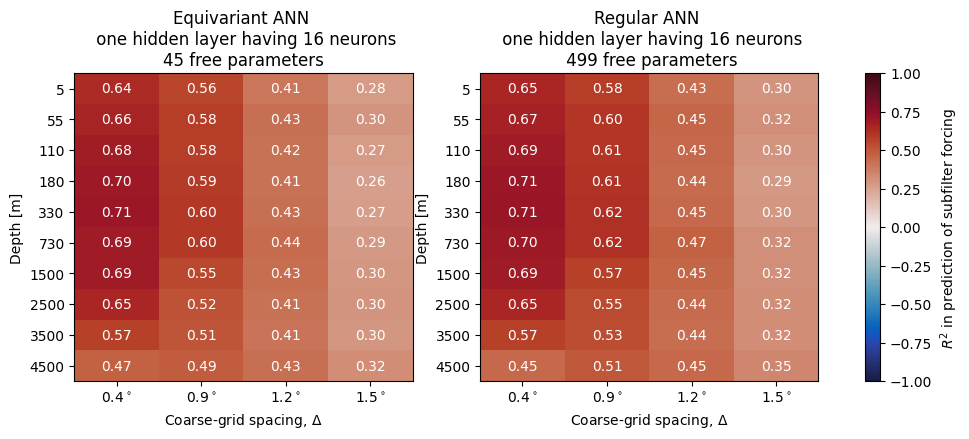

In [140]:
plt.figure(figsize=(12,4))
metric = 'R2'
plt.subplot(1,2,1)
plot_metric(dd['16-v1'], metric=metric)
plt.title('Equivariant ANN \n one hidden layer having 16 neurons\n45 free parameters')

plt.subplot(1,2,2)
im = plot_metric(dd['exp1-16'], metric=metric)
plt.title('Regular ANN \n one hidden layer having 16 neurons\n 499 free parameters')

plt.colorbar(im, ax=plt.gcf().axes, label='$R^2$ in prediction of subfilter forcing')

In [132]:
from helpers.ann_tools import ANN_equivariant, export_ANN, import_ANN, ANN
ANN(layer_sizes=[27,16,3]).count_parameters()

499

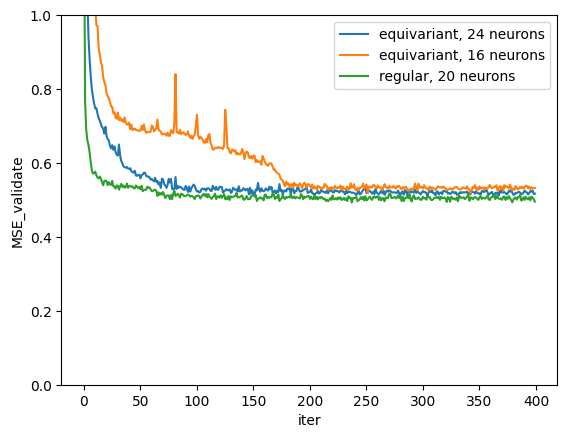

In [77]:
dd['24-v1']['stats'].MSE_validate.mean(['factor', 'depth']).plot(label='equivariant, 24 neurons')
dd['16-v1']['stats'].MSE_validate.mean(['factor', 'depth']).plot(label='equivariant, 16 neurons')
dd['exp1']['stats'].MSE_validate.mean(['factor', 'depth']).plot(label='regular, 20 neurons')

plt.ylim([0,1])
plt.legend()

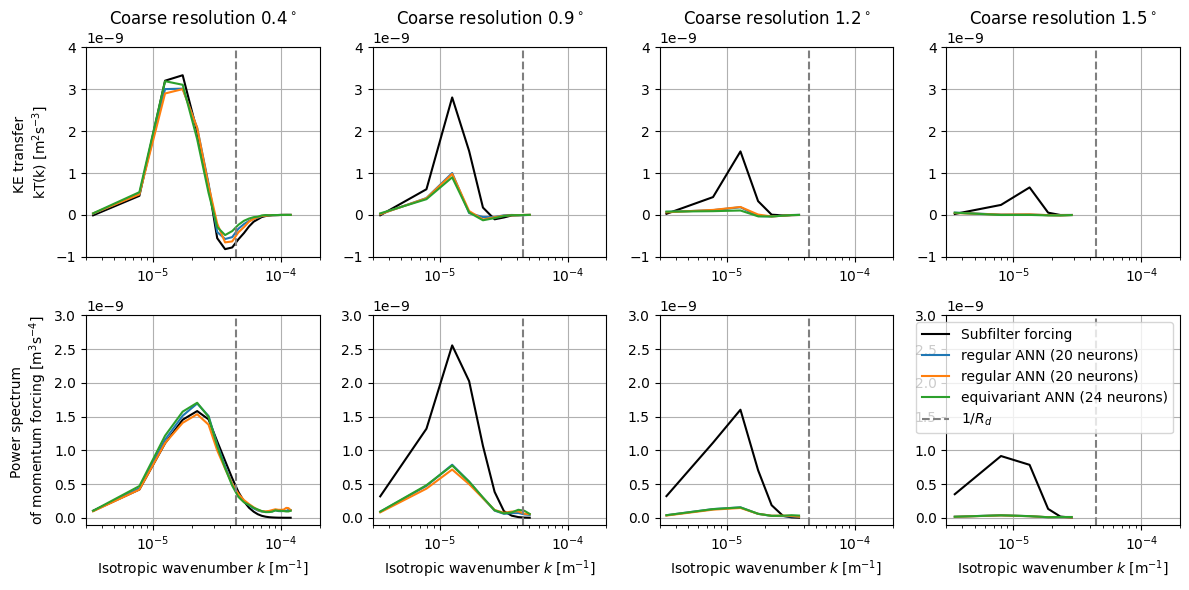

In [86]:
plt.figure(figsize=(12,6))

for column, factor, resolution in zip([0,1,2,3],[4,9,12,15],['$0.4^\circ$', '$0.9^\circ$', '$1.2^\circ$', '$1.5^\circ$']):
    plt.subplot(2,4,column+1)
    dd['exp1'][factor].transfer_NA.mean('time').isel(zl=0).plot(color='k', label='Subfilter forcing')
    dd['exp1'][factor].transfer_ZB_NA.mean('time').isel(zl=0).plot(label='regular ANN (20 neurons)')
    dd['exp2'][factor].transfer_ZB_NA.mean('time').isel(zl=0).plot(label='regular ANN (20 neurons)')
    #dd['16-v1'][factor].transfer_ZB_NA.mean('time').isel(zl=0).plot(label='equivariant ANN (16 neurons)')
    dd['24-v1'][factor].transfer_ZB_NA.mean('time').isel(zl=0).plot(label='equivariant ANN (24 neurons)')
    plt.xscale('log')
    plt.title(f'Coarse resolution {resolution}')
    plt.tight_layout()
    plt.xlabel('')
    if column==0:
        plt.ylabel('KE transfer \nkT(k) [m$^2$s$^{-3}$]')
    else:
        plt.ylabel('')
    plt.xlim([3e-6, 2e-4])
    plt.ylim([-1e-9, 4e-9])
    plt.grid()
    plt.axvline(x=1/(22.6e+3), color='tab:gray', ls='--')

    plt.subplot(2,4,column+5)
    dd['exp1'][factor].power_NA.mean('time').isel(zl=0).plot(color='k', label='Subfilter forcing')
    dd['exp1'][factor].power_ZB_NA.mean('time').isel(zl=0).plot(label='regular ANN (20 neurons)')
    dd['exp2'][factor].power_ZB_NA.mean('time').isel(zl=0).plot(label='regular ANN (20 neurons)')
    #dd['16-v1'][factor].power_ZB_NA.mean('time').isel(zl=0).plot(label='equivariant ANN (16 neurons)')
    dd['24-v1'][factor].power_ZB_NA.mean('time').isel(zl=0).plot(label='equivariant ANN (24 neurons)')
    plt.xscale('log')
    #plt.yscale('log')
    plt.title('')
    plt.tight_layout()
    plt.xlabel('Isotropic wavenumber $k$ [$\mathrm{m}^{-1}$]')
    if column==0:
        plt.ylabel('Power spectrum \nof momentum forcing [m$^3$s$^{-4}$]')
    else:
        plt.ylabel('')
    plt.xlim([3e-6, 2e-4])
    plt.ylim([-0.1e-9, 3e-9])
    plt.grid()
    plt.axvline(x=1/(22.6e+3), color='tab:gray', ls='--')

plt.plot(np.nan, np.nan, color='tab:gray', ls='--', label='$1/R_d$')
plt.legend()

Correlation: 0.8450997471809387
Relative Error: 0.5417686104774475
R2 =  0.7007103264331818
R2 max =  0.7141935527324677
Optinal scaling: 0.8791977167129517
Nans [test/control]: [15938, 15938]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xq', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xq', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xq', ylabel='yh'>,
        <Axes: >]], dtype=object)

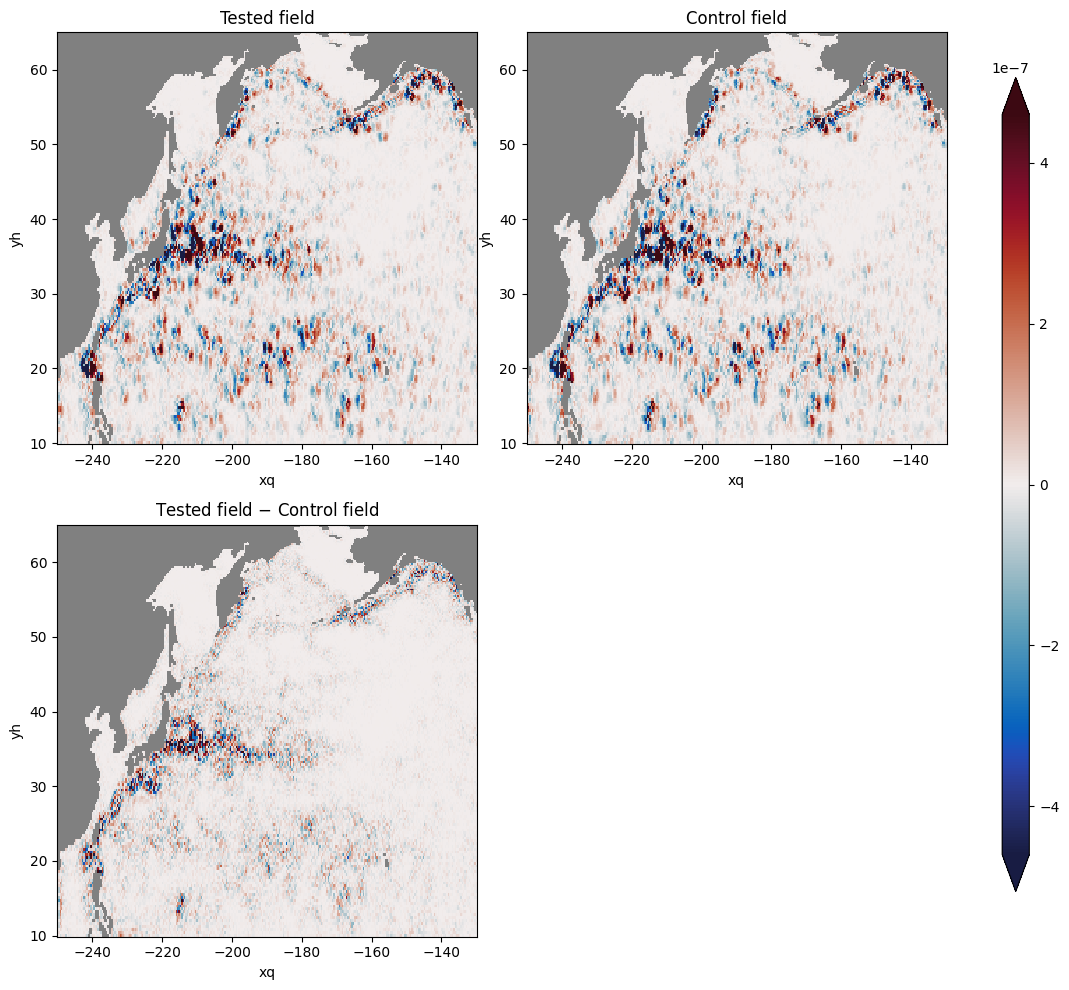

In [109]:
compare(dd['16-v1'][4].ZB20u[0], dd['exp1'][4].ZB20u[0], selector=select_Pacific)

# Test online

In [1]:
import sys
import xarray as xr
sys.path.append('/home/pp2681/calibration/src-double-gyre')
sys.path.append('/home/pp2681/calibration/src')
import plot_helpers

In [2]:
from helpers.collection_of_experiments import CollectionOfExperiments

In [3]:
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [4]:
ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration', additional_subfolder='output')

In [5]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization', additional_subfolder='output')

In [6]:
ds.remesh('R64', 'R4')

/ext3/miniconda3/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4


/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)


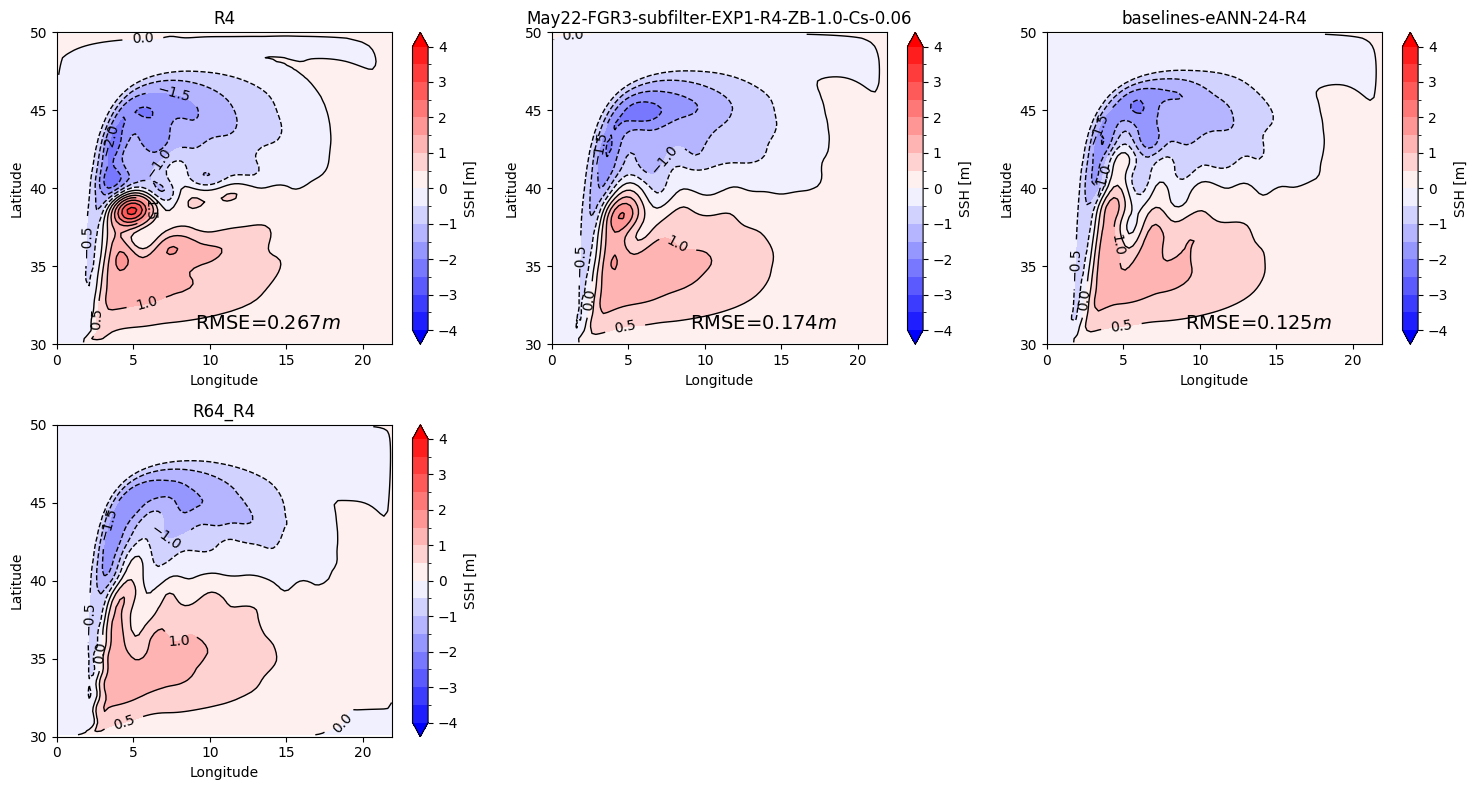

In [14]:
ds.plot_ssh(['R4', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'baselines-eANN-24-R4', 'R64_R4'])

/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/ext3/miniconda3/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2140: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)


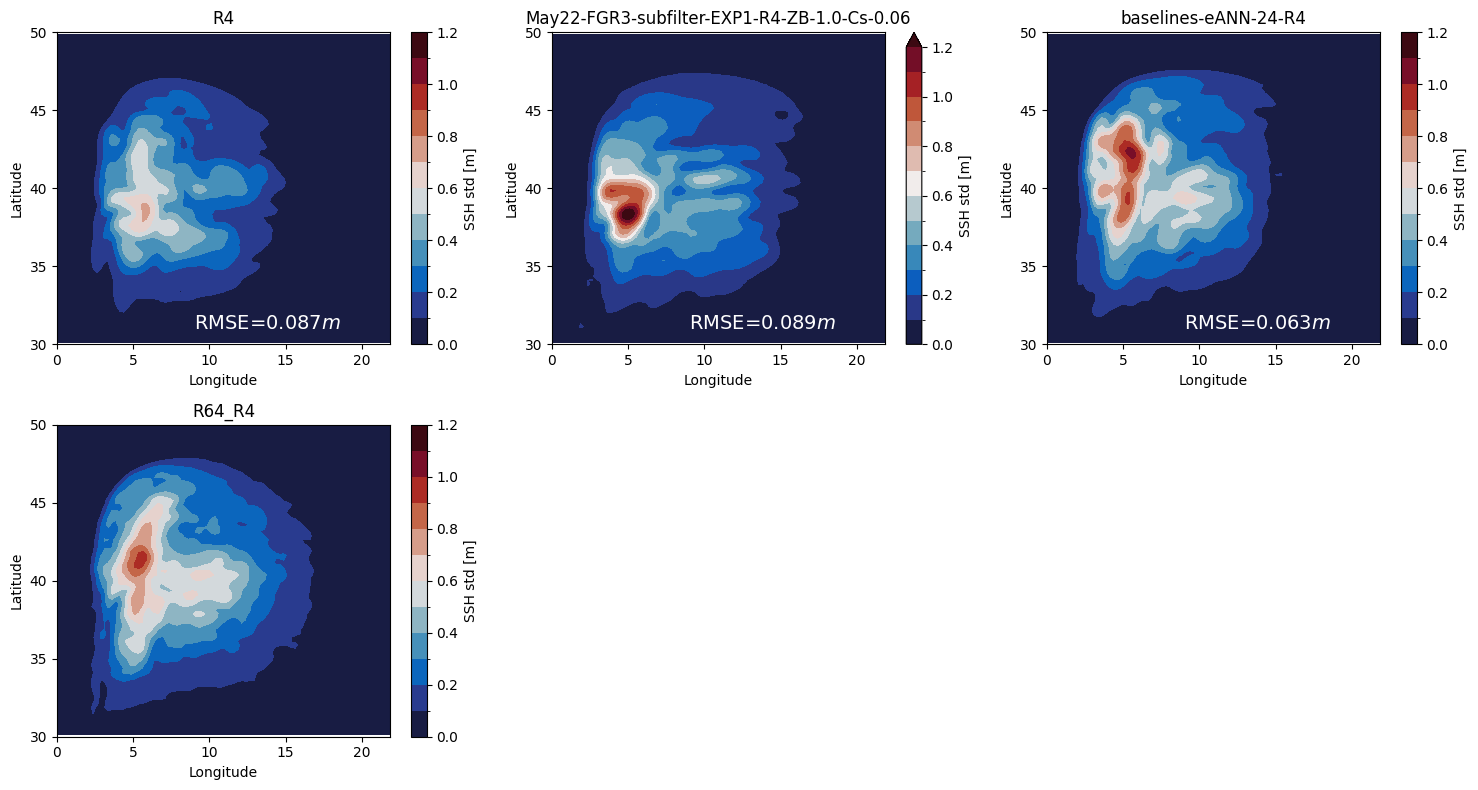

In [23]:
ds.plot_ssh_std(['R4', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'baselines-eANN-24-R4', 'R64_R4'], target='R64_R4')

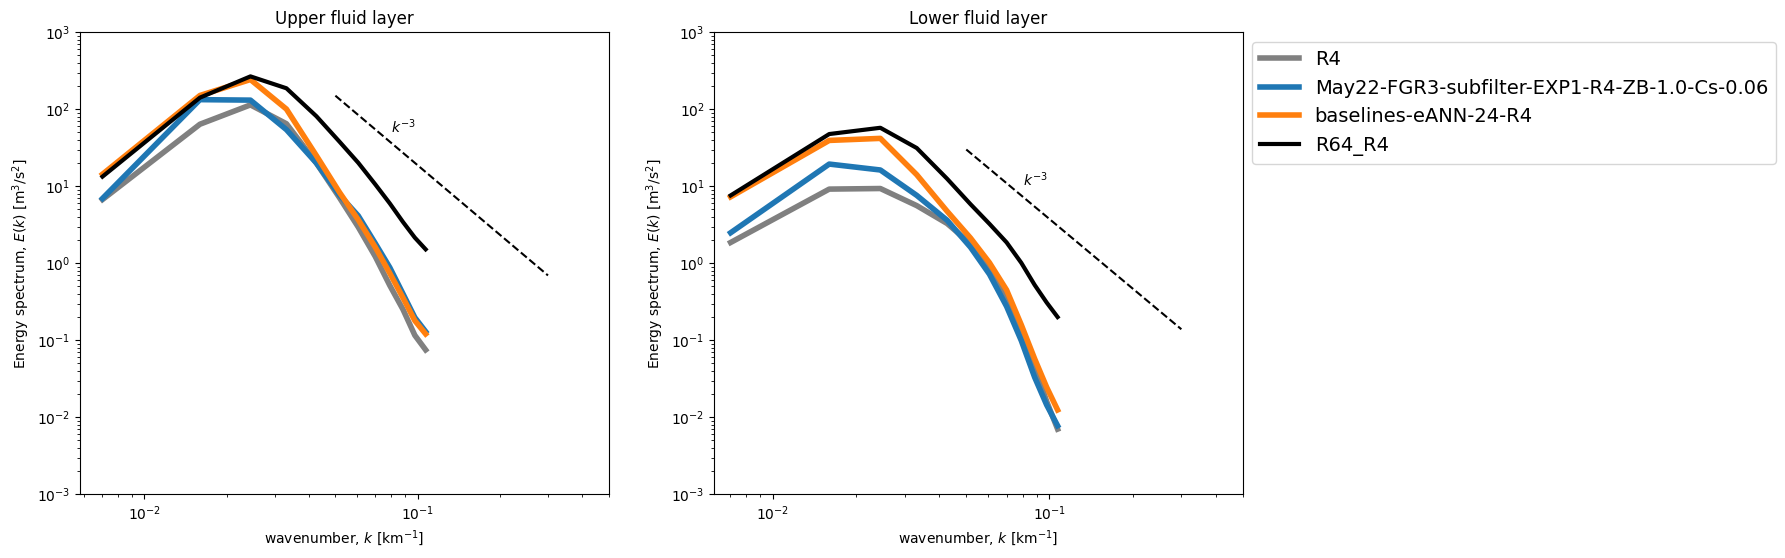

In [42]:
ds.plot_KE_spectrum(['R4', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'baselines-eANN-24-R4', 'R64_R4'])

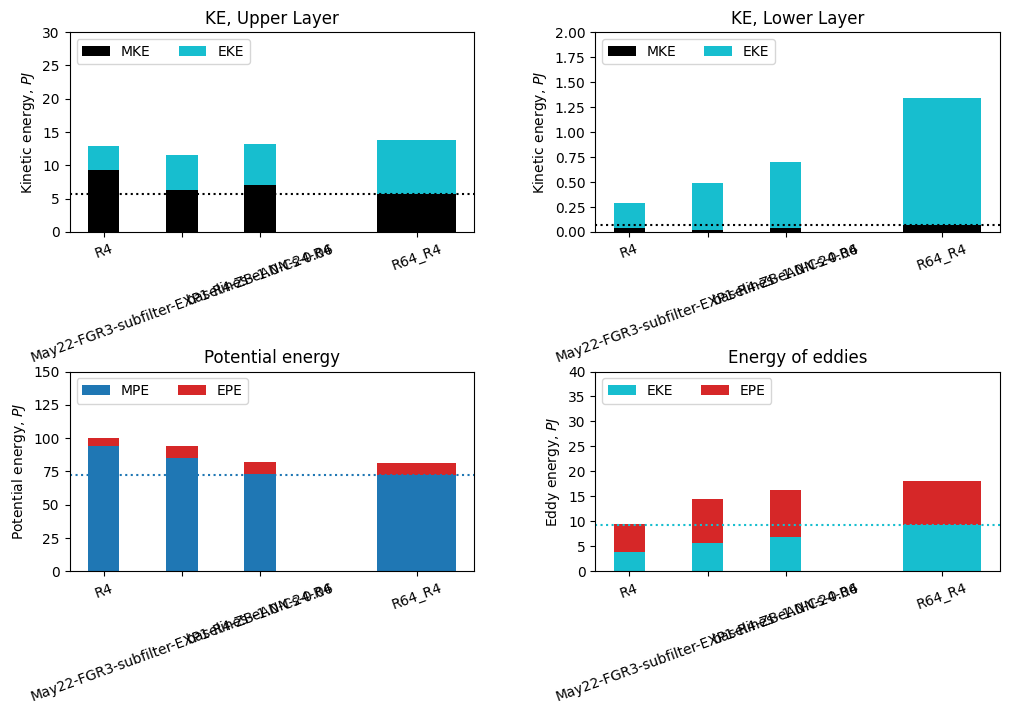

In [43]:
ds.plot_KE_PE(['R4', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'baselines-eANN-24-R4', 'R64_R4'])

In [7]:
from plot_helpers import create_animation_ffmpeg

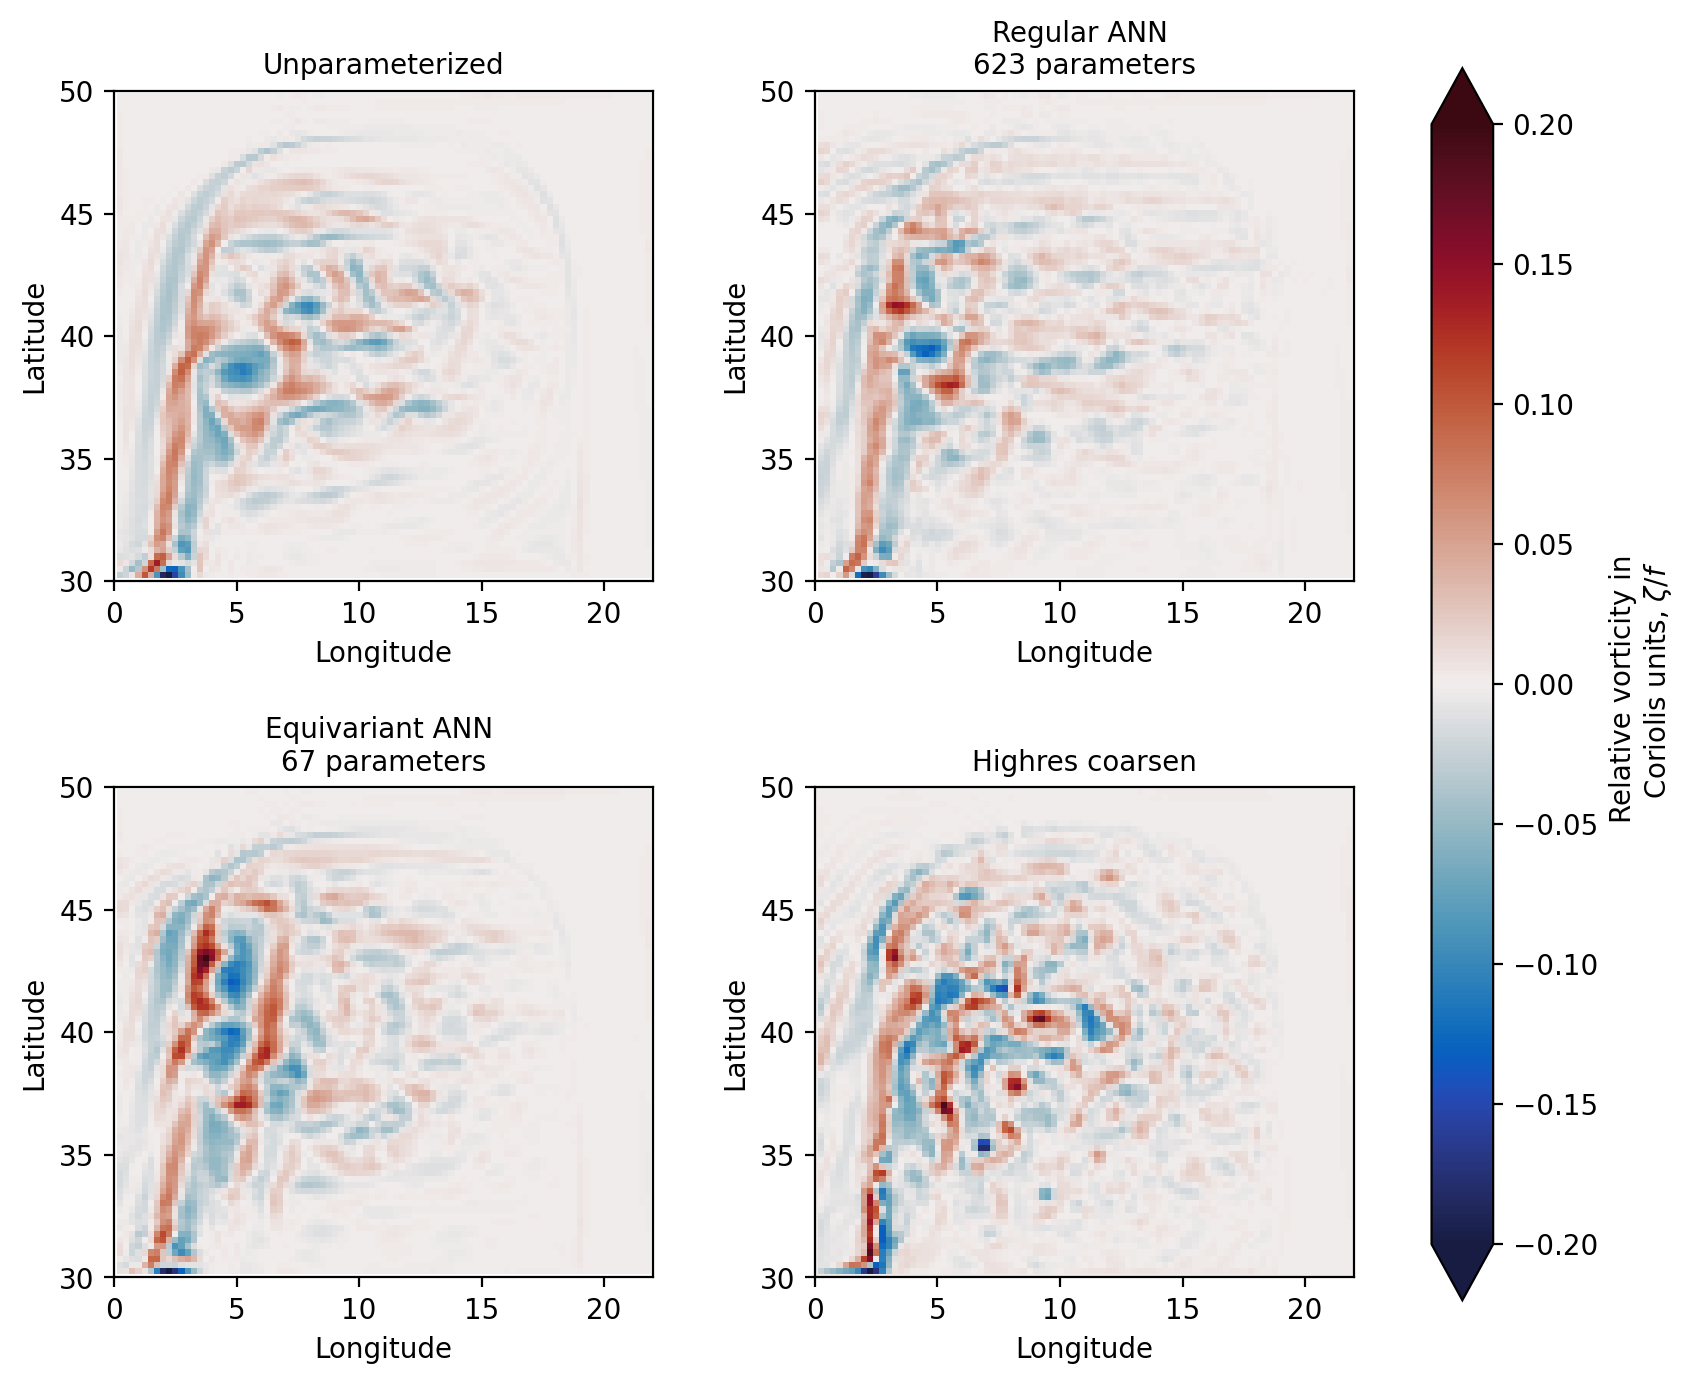

In [15]:
def plot(idx=-1):
    ds.plot_RV(['R4', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'baselines-eANN-24-R4', 'R64_R4'], ncols=2,
    labels=['Unparameterized', 'Regular ANN \n623 parameters', 'Equivariant ANN \n67 parameters', 'Highres coarsen'], idx=idx)
plot()

In [16]:
create_animation_ffmpeg(plot, idx=range(60,120), filename='eANN_R4.mp4')

Savefig .ffmpeg/eANN_R4/frame-0.png
Savefig .ffmpeg/eANN_R4/frame-1.png33664703369
Savefig .ffmpeg/eANN_R4/frame-2.png4344959259
Savefig .ffmpeg/eANN_R4/frame-3.png7643254598
Savefig .ffmpeg/eANN_R4/frame-4.png7835855484
Savefig .ffmpeg/eANN_R4/frame-5.png8532714844
Savefig .ffmpeg/eANN_R4/frame-6.png3560180664
Savefig .ffmpeg/eANN_R4/frame-7.png4723445347
Savefig .ffmpeg/eANN_R4/frame-8.png8161664009
Savefig .ffmpeg/eANN_R4/frame-9.png1553955078
Savefig .ffmpeg/eANN_R4/frame-10.png426994324
Savefig .ffmpeg/eANN_R4/frame-11.png0842618075
Savefig .ffmpeg/eANN_R4/frame-12.png6313168208
Savefig .ffmpeg/eANN_R4/frame-13.png9334388146
Savefig .ffmpeg/eANN_R4/frame-14.png4288136618
Savefig .ffmpeg/eANN_R4/frame-15.png38719177245
Savefig .ffmpeg/eANN_R4/frame-16.png8051588535
Savefig .ffmpeg/eANN_R4/frame-17.png2466762767
Savefig .ffmpeg/eANN_R4/frame-18.png9214674632
Savefig .ffmpeg/eANN_R4/frame-19.png2477914911
Savefig .ffmpeg/eANN_R4/frame-20.png0573720932
Savefig .ffmpeg/eANN_R4/frame-21

ffmpeg version 4.2.4-1ubuntu0.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.3.0-10ubuntu2)
  configuration: --prefix=/usr --extra-version=1ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-l